In [ ]:
# Requirement.txt
#pandas==2.2.2
#numpy==1.26.4
#scikit-learn==1.4.2
#matplotlib==3.8.4
#torch==2.1.0+cpu
#torchaudio==2.1.0+cpu


## Step-1 Action

```bash
pip uninstall tensorflow  # If only using PyTorch
# OR
pip uninstall torch  # If only using TensorFlow
```

## Step 2: Use CPU-only Versions (if GPU not mandatory)

### ⚙️ Save Disk Space by Using CPU-Only Versions

If **inference latency is not crucial**, switching to CPU-only versions of deep learning libraries can **reduce disk space usage** by approximately **~2.5 GB** (by avoiding NVIDIA/CUDA dependencies).

---

#### 🔄 Replace GPU versions with CPU-only versions

```bash
# Uninstall existing GPU-based PyTorch libraries
pip uninstall torch torchvision torchaudio

# Install CPU-only versions of PyTorch
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
```

### 🧰 Step 3: Use Lightweight Alternatives

Some heavyweight packages can be replaced with lighter alternatives to reduce environment size and improve efficiency:

| **Current Library**              | **Lighter Alternative**        | **Notes**                                                   |
|----------------------------------|--------------------------------|-------------------------------------------------------------|
| `matplotlib` (27 MB)            | `plotly` or `seaborn`         | `plotly` is interactive and lighter.                        |
| `scipy` (135 MB)                | `numpy`, `jax`, `numba`       | Depends on usage — `jax` is GPU-aware and highly performant. |
| `fontTools` (24 MB)             | _Remove if no custom fonts_   | Check if it's truly needed in your pipeline.               |
| `tensorflow_io_gcs_filesystem` | _Remove if no GCS used_       | TensorFlow can read local files without it.                |

---

✅ **Tip**: Regularly audit your dependencies to eliminate unused or heavy libraries that don’t add value to your specific workflow.


### 🧩 Step 4: Modularize Your Environment

Split your environment into **Training** and **Inference** setups for better control and reduced size:

- **Training**: Heavy and full-featured  
  _Includes tools like TensorBoard, cloud plugins (e.g., GCS), etc._
  
- **Inference**: Slim and minimal  
  _Contains only the essential runtime libraries needed for deployment._

---

#### 🔧 Tool Tip: Use `pipreqs` to auto-generate `requirements.txt` with only used libraries

```bash
# Install pipreqs
pip install pipreqs

# Generate minimal requirements.txt for your project
pipreqs /path/to/your/project


### 🧊 Step 5: Freeze and Use Minimal Docker or Conda Environments

Optimize your production setup by freezing dependencies and choosing lightweight base environments:

---

#### 🧪 Conda Tip: Use `--no-deps` to manually control installations

```bash
# Install a package without pulling all dependencies automatically
conda install <package-name


### ✂️ Step 6: Optional - Quantize or Prune the Model

If your model is large and deployment size or speed is critical, consider **quantization** or **pruning**.

---

#### ⚙️ Techniques:

- **TensorFlow** → Use **TensorFlow Lite** with post-training quantization
- **PyTorch** → Use **TorchScript** + dynamic or static quantization

---

#### 🎯 Benefits:

- ✅ Smaller model binary (often **4x smaller**)
- ✅ Faster inference on edge devices
- ✅ Removes dependency on full TensorFlow or PyTorch frameworks

---

💡 Ideal for mobile, embedded, or serverless inference environments!


### 📦 Optimization Changes in previous?

| **Optimization**                                | **Space Saved** |
|--------------------------------------------------|-----------------|
| Removed one of TensorFlow              | ~1.5 GB         |
| Switch to CPU-only versions                     | ~2.5 GB         |
| Drop unused libraries (matplotlib, GCS, fontTools) | ~70 MB          |
| Use lighter plotting / math libraries           | ~100 MB         |


---

✅ These savings **add up significantly**, especially in resource-constrained deployments (e.g., cloud functions, mobile, Docker containers).


In [17]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses

In [29]:
# Set random seed for reproducibility
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

In [30]:
# Load the dataset
file_path = 'profiles-employees-makemytrip.csv'  # Update the path to your dataset
data = pd.read_csv(file_path)

In [31]:
# Step 1: Preprocess the data
numerical_columns = data.select_dtypes(include='number')

# Handle missing values with mean imputation
imputer = SimpleImputer(strategy="mean")
numerical_data = pd.DataFrame(imputer.fit_transform(numerical_columns), columns=numerical_columns.columns)

# Normalize the data
scaler = StandardScaler()
normalized_data = scaler.fit_transform(numerical_data)

In [32]:
# Step 2: Define the Attention-Based Autoencoder
def build_attention_autoencoder(input_dim, latent_dim):
    inputs = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(64, activation='relu')(inputs)
    latent = layers.Dense(latent_dim)(encoded)
    attention = layers.Dense(latent_dim, activation='softmax')(latent)
    attended = layers.Multiply()([latent, attention])
    decoded = layers.Dense(64, activation='relu')(attended)
    outputs = layers.Dense(input_dim)(decoded)
    return models.Model(inputs, outputs), models.Model(inputs, attended)

In [33]:
# Step 3: Train the Autoencoder
input_dim = normalized_data.shape[1]
latent_dim = 15
autoencoder, encoder = build_attention_autoencoder(input_dim, latent_dim)
autoencoder.compile(optimizer=optimizers.Adam(0.001), loss=losses.MeanSquaredError())

In [34]:
# Fit the model
history = autoencoder.fit(normalized_data, normalized_data,
                          epochs=100, verbose=0)

In [35]:
# Extract latent representations
latent_representation = encoder.predict(normalized_data)

1/1 [==============================] - 0s 57ms/step


In [36]:
# Step 4: Apply t-SNE on latent representations
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
tsne_result = tsne.fit_transform(latent_representation)

In [37]:
# Step 5: KMeans Clustering and Silhouette Scores
results = []
for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(latent_representation)
    silhouette_avg = silhouette_score(latent_representation, clusters)
    results.append((k, silhouette_avg))

# Determine the best k
best_k = max(results, key=lambda x: x[1])[0]

In [38]:
# Apply KMeans with the best k
best_kmeans = KMeans(n_clusters=best_k, random_state=42)
best_clusters = best_kmeans.fit_predict(latent_representation)

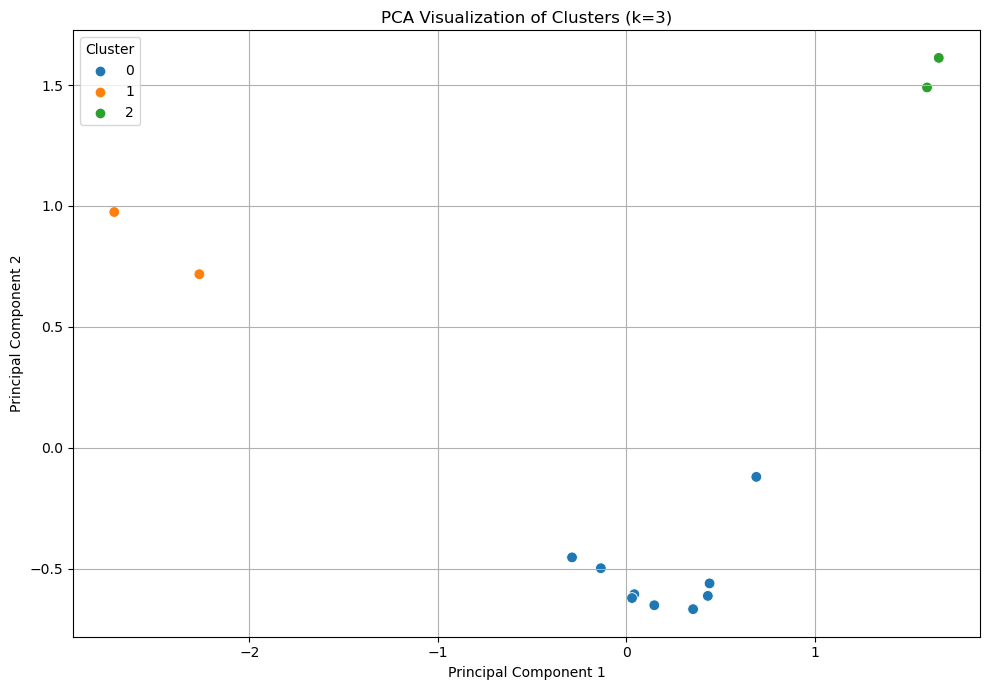

In [39]:
# Step 6: PCA for Visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(latent_representation)

# Plot PCA results using seaborn
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['Cluster'] = best_clusters

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', s=60)
plt.title(f'PCA Visualization of Clusters (k={best_k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

In [40]:
# Display silhouette scores
results_df = pd.DataFrame(results, columns=['Number of Clusters (k)', 'Silhouette Score'])
print("Silhouette Scores for Clusters:")
print(results_df)

Silhouette Scores for Clusters:
   Number of Clusters (k)  Silhouette Score
0                       2          0.686391
1                       3          0.831555
2                       4          0.588267


In [41]:
# Identify the max-density cluster
max_density_cluster_id = pd.Series(best_clusters).value_counts().idxmax()
max_density_cluster_centroid = best_kmeans.cluster_centers_[max_density_cluster_id]
max_density_cluster = numerical_data[best_clusters == max_density_cluster_id]

print("\nMax-Density Cluster Profile:")
print(f"Centroid (Latent Space): {max_density_cluster_centroid}")
print("Cluster Profile (Mean):")
print(max_density_cluster.mean())
print(f"Cluster Count: {len(max_density_cluster)}")

# Step 7: Test Data Similarity
# Simulate test data (new observation)
test_data = normalized_data[:5]
test_latent = encoder.predict(test_data)
similarities = cosine_similarity(test_latent, [max_density_cluster_centroid])

# Categorize similarities
categories = ["Low" if sim < 0.7 else "Medium" if sim < 0.85 else "High" if sim < 0.95 else "Very High" for sim in similarities.flatten()]
print("\nTest Data Similarity Categories:")
for i, category in enumerate(categories):
    print(f"Test Point {i+1}: {category}")


Max-Density Cluster Profile:
Centroid (Latent Space): [ 0.0095012   0.09986767 -0.00524386 -0.00137914  0.04909582 -0.01211107
  0.07227059 -0.00761272 -0.00824872  0.04456783 -0.00353315 -0.00578358
 -0.20593539 -0.02333506  0.0457058 ]
Cluster Profile (Mean):
Extraversion         5.622222
Neuroticism          7.765556
Agreeableness        4.692222
Conscientiousness    5.530000
Openness             7.310000
dtype: float64
Cluster Count: 9
1/1 [==============================] - 0s 16ms/step

Test Data Similarity Categories:
Test Point 1: Low
Test Point 2: Low
Test Point 3: Medium
Test Point 4: Low
Test Point 5: Medium
